In [12]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# READ THE BANGALORE HOUSE PRICE DATASET (ONE-HOT ENCODED)
houses = pd.read_csv(
    "C:\\Users\\Admin\\Documents\\arc_model_core\\ml_docs\\Datasets\\banglore_house-price_OHE.csv"
)
houses.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [13]:
# DISPLAY DATASET INFORMATION (DATA TYPES, NON-NULL COUNTS)
houses.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [14]:
# CHECK FOR MISSING VALUES IN EACH COLUMN
print("=>> MISSING VALUES PER COLUMN >>")
display(houses.isnull().sum())

=>> MISSING VALUES PER COLUMN >>


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [15]:
# FUNCTION TO CONVERT SQUARE FEET VALUES TO FLOAT
def CONVERT_SQFT_TO_FLOAT(x):
    """
    Convert square feet values to float.
    Handles ranges like '1200-1500' by taking the average.
    """
    try:
        if "-" in str(x):
            lower, upper = x.split("-")
            return (float(lower) + float(upper)) / 2
        return float(x)
    except:
        return np.nan

In [16]:
# DEFINE NUMERICAL AND CATEGORICAL COLUMNS FOR IMPUTATION
numrical_columns = ["bath", "balcony"]
categorical_columns = ["location", "size", "society"]


# IMPUTE CATEGORICAL COLUMNS WITH MODE (MOST FREQUENT VALUES)
for col in categorical_columns:
    houses[col] = houses[col].fillna(houses[col].mode()[0])

# IMPUTE NUMERICAL COLUMNS WITH MEAN VALUES
for num in numrical_columns:
    houses[num] = houses[num].fillna(houses[num].mean())


# APPLY SQUARE FEET CONVERSION FUNCTION
houses["total_sqft"] = houses["total_sqft"].apply(CONVERT_SQFT_TO_FLOAT)

# REMOVE ANY ROWS WITH MISSING VALUES AFTER CONVERSION
houses.dropna(inplace=True)

In [17]:
# SEPARATE FEATURES AND TARGET VARIABLE
# APPLY ONE-HOT ENCODING TO CATEGORICAL COLUMNS
X = pd.get_dummies(houses.drop("price", axis=1), drop_first=True, dtype=np.int8)
y = houses["price"]


# SPLIT THE DATA INTO TRAINING AND TESTING SETS (80% TRAIN, 20% TEST)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=51
)

In [18]:
# DISPLAY THE SHAPES OF ALL DATASETS
print(f":> FEATURES SHAPE (X): {X.shape}")
print(f":> TARGET SHAPE (y): {y.shape}")

print(f"\n:> TRAINING FEATURES SHAPE (X_train): {X_train.shape}")
print(f":> TESTING FEATURES SHAPE (X_test): {X_test.shape}")
print(f":> TRAINING TARGET SHAPE (y_train): {y_train.shape}")
print(f":> TESTING TARGET SHAPE (y_test): {y_test.shape}")

:> FEATURES SHAPE (X): (13274, 4099)
:> TARGET SHAPE (y): (13274,)

:> TRAINING FEATURES SHAPE (X_train): (10619, 4099)
:> TESTING FEATURES SHAPE (X_test): (2655, 4099)
:> TRAINING TARGET SHAPE (y_train): (10619,)
:> TESTING TARGET SHAPE (y_test): (2655,)


In [19]:
# INITIALIZE STANDARD SCALER FOR FEATURE NORMALIZATION
scaler = StandardScaler()


# APPLY STANDARD SCALING TO TRAINING AND TEST DATA
X_train = scaler.fit_transform(X_train)  # FIT AND TRANSFORM ON TRAINING DATA
X_test = scaler.transform(X_test)  # ONLY TRANSFORM ON TESTING DATA

In [20]:
# TRAIN SVR WITH RBF KERNEL
print("=>> TRAINING SVR WITH RBF KERNEL >>")
start_time = time.time()

svr_rbf = SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.1, cache_size=1000)
svr_rbf.fit(X_train, y_train)

rbf_score = svr_rbf.score(X_test, y_test)
training_time_rbf = time.time() - start_time


print(f":> R² SCORE: {rbf_score:.4f}")
print(f":> TRAINING TIME: {training_time_rbf:.2f} seconds")

=>> TRAINING SVR WITH RBF KERNEL >>
:> R² SCORE: 0.1159
:> TRAINING TIME: 456.38 seconds


In [21]:
# TRAIN LINEAR SVR
print("=>> TRAINING LINEAR SVR >>")
svr_linear = LinearSVR(random_state=42, max_iter=1000)
svr_linear.fit(X_train, y_train)

linear_score = svr_linear.score(X_test, y_test)
print(f":> R² SCORE: {linear_score:.4f}")

=>> TRAINING LINEAR SVR >>
:> R² SCORE: 0.5375


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [22]:
# TRAIN SVR WITH POLYNOMIAL KERNEL (DEGREE 2)
print("=>> TRAINING SVR WITH POLYNOMIAL KERNEL (Degree 2) >>")
svr_poly = SVR(kernel="poly", degree=2)
svr_poly.fit(X_train, y_train)

poly_score = svr_poly.score(X_test, y_test)
print(f":> R² SCORE: {poly_score:.4f}")

=>> TRAINING SVR WITH POLYNOMIAL KERNEL (Degree 2) >>
:> R² SCORE: -0.0492


In [23]:
# COMPARE ALL MODELS
print("=>> MODEL PERFORMANCE COMPARISON >>")
print("=" * 40)
print(f":> RBF Kernel R² Score: {rbf_score:.4f}")
print(f":> Linear Kernel R² Score: {linear_score:.4f}")
print(f":> Polynomial Kernel R² Score: {poly_score:.4f}")
print(
    f":> Best Model: {'RBF' if rbf_score > linear_score and rbf_score > poly_score else 'Linear' if linear_score > poly_score else 'Polynomial'}"
)

=>> MODEL PERFORMANCE COMPARISON >>
:> RBF Kernel R² Score: 0.1159
:> Linear Kernel R² Score: 0.5375
:> Polynomial Kernel R² Score: -0.0492
:> Best Model: Linear


In [24]:
# MAKE PREDICTION FOR FIRST TEST SAMPLE USING LINEAR SVR
sample_prediction = svr_linear.predict([X_test[0]])

print(f":> ACTUAL PRICE: ₹{y_test.iloc[0]:,.2f}")
print(f":> SAMPLE PREDICTION (First Test Sample): ₹{sample_prediction[0]:,.2f}")

:> ACTUAL PRICE: ₹87.00
:> SAMPLE PREDICTION (First Test Sample): ₹110.71


In [25]:
# MAKE PREDICTIONS ON THE ENTIRE TEST SET USING LINEAR SVR
y_predicted = svr_linear.predict(X_test)

# CALCULATE EVALUATION METRICS
mse = mean_squared_error(y_test, y_predicted)  # MEAN SQUARED ERROR
rmse = np.sqrt(mse)  # ROOT MEAN SQUARED ERROR

In [30]:
# DISPLAY THE EVALUATION METRICS
print("=>> MODEL EVALUATION METRICS (Linear SVR) >>")
print("=" * 45)
print(f":> MEAN SQUARED ERROR (MSE): ₹{mse:,.2f}")
print(f":> ROOT MEAN SQUARED ERROR (RMSE): ₹{rmse:,.2f}")

=>> MODEL EVALUATION METRICS (Linear SVR) >>
:> MEAN SQUARED ERROR (MSE): ₹12,793.54
:> ROOT MEAN SQUARED ERROR (RMSE): ₹113.11


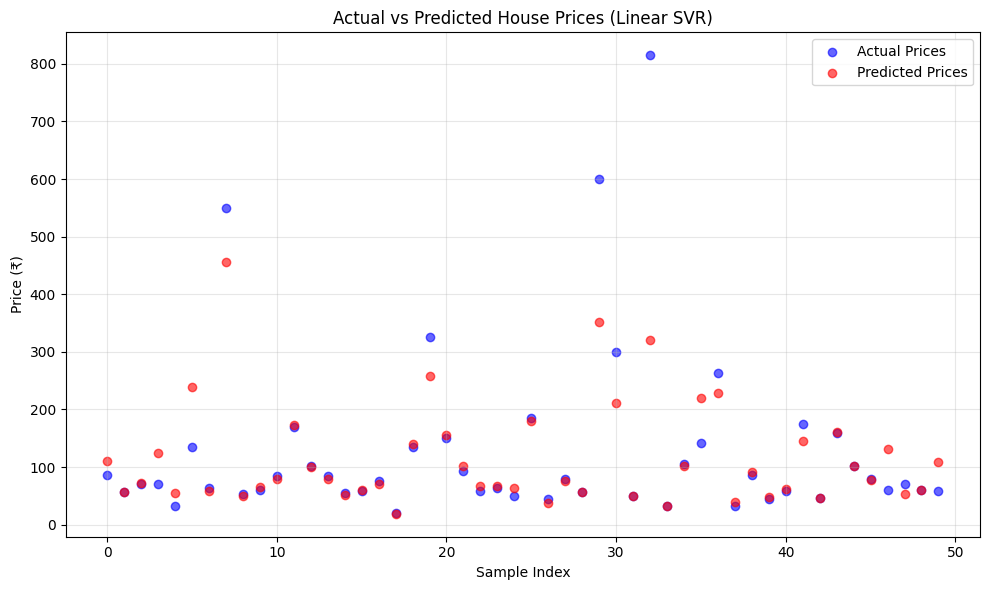

In [27]:
# OPTIONAL: VISUALIZE PREDICTED VS ACTUAL (First 50 samples)
plt.figure(figsize=(10, 6))
sample_size = min(50, len(y_test))

plt.scatter(
    range(sample_size),
    y_test[:sample_size],
    color="blue",
    alpha=0.6,
    label="Actual Prices",
)

plt.scatter(
    range(sample_size),
    y_predicted[:sample_size],
    color="red",
    alpha=0.6,
    label="Predicted Prices",
)

plt.xlabel("Sample Index")
plt.ylabel("Price (₹)")
plt.title("Actual vs Predicted House Prices (Linear SVR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()